# 🚗 Predicting Car Prices with Machine Learning

Welcome, data explorers! 👩‍💻👨‍💻🚀

Imagine you're browsing through a car dealership’s website and wondering — *"Why is this car more expensive than that one?"* 🤔  
Well, today **you’re the data scientist behind the scenes**, building a model that helps answer exactly that.

In this case study, you and your team will work on an **end-to-end machine learning project** to **predict car prices** based on various features like the model, year, mileage, fuel type, and more. We'll be using a real-world dataset from the automotive market — noisy, messy, and full of patterns waiting to be discovered. 🧠📊

You'll walk through the full ML pipeline:  
- Cleaning and preprocessing the data 🧹  
- Exploring the hidden relationships 🔍  
- Building and tuning regression models 🛠️  
- Evaluating how well your model performs 📈  
- And maybe... deploying it? (ambitious, but hey — dream big!)

By the end of this notebook, you’ll have built a model that can **predict the price of a car**, and more importantly, you'll understand how to tackle real-world machine learning problems from scratch.

Let’s rev up our engines and start predicting! 🏁💥


#### First, let's take a look at our dataset

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/predict_prices_dataset.csv')
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4,audi
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0,audi
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0,audi
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4,audi
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4,audi


#### 2. Explore the Dataset (EDA - Exploratory Data Analysis)
Understand the structure and content:

Shape of the dataset

Data types

Missing values

Statistical summary

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  int64  
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 5.5 MB


In [4]:
# Summary statistics
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16579.987506,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.218027,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,99.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


#### Let's get some insights

🔧 Year: 
- Mean year of cars is ~2017, with a range from 1996 to 2020.
- 75% of the cars are from 2016 or newer, indicating the dataset is mostly composed of recent vehicles.
- The standard deviation (~2.1 years) shows low year variability — mostly modern cars.

💰 Price
- Car prices range from as low as £495 to £145,000 — this is a huge spread, likely including luxury and budget models.
- The average price is around £16,580, with a median of £14,495, suggesting a right-skewed distribution (some very expensive outliers).

🛣️ Mileage
- Mileage spans from 0 to 323,000 miles — a massive range.
- Median mileage is around 17,531, and the mean is 23,176, again showing a right-skewed distribution (many high-mileage cars).

💸 Tax
- Tax ranges from £0 to £580, with a median of £145, which likely reflects common tax bands.
- Mean tax is ~£117, and 75% of cars fall below £145 — outliers should be reviewed here as well.

⛽ MPG (Miles per Gallon)
- Extremely wide range from 0.3 to 470.8 MPG — the upper value is almost certainly an anomaly or data entry error (possibly electric vehicles with an equivalent mpg).
- Median of 55.4 MPG, and average of ~55.85, suggesting mostly fuel-efficient vehicles.

🔧 Engine Size
- Engine sizes range from 0.0 to 6.6 liters, with median = 1.6L, which aligns with common car engines.
- Some 0.0 engine sizes might indicate missing or erroneous values.
- Values above 4.0L likely belong to high-performance/luxury cars.

#### Do we have missing values??

In [7]:
# Check for missing values
df.isnull().sum()
# df.fillna(0).count()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

###### Handling Missing Values – Quick Decision Guide

---

###### 1) Identify Feature Type
- **Categorical (`make`, `model`)** → Mode, `"Unknown"`, or predictive modeling  
- **Numerical (`price`, `mileage`, `engineSize`)** → Mean/Median, group-wise stats, or regression/KNN  
- **Ordinal (e.g., condition 1–5)** → Median or interpolation  

---

###### 2) Check Missingness Percentage
- **<5%** → Simple imputation (mean/median/mode)  
- **5–30%** → Group-wise or model-based imputation  
- **>30%** → Consider dropping or advanced methods  

---

###### 3) Determine Missingness Mechanism
- **MCAR** (*Completely Random – e.g., data entry errors*) → Mean/median (num), Mode (cat)  
- **MAR** (*Depends on other features – e.g., mileage missing in new cars*) → Group-wise, Regression, or KNN  
- **MNAR** (*Depends on the value itself – e.g., high-priced cars hiding price*) → Keep as `NaN`, or add `"missing"` flag  

---

###### 4) Check Data Ordering
- **Sequential/Time-series** → FFILL/BFILL **within groups only**  
- **Unordered (typical listings)** → Prefer statistical or model-based methods; **avoid FFILL/BFILL**  

---

###### 5) Quick Reference Table

| Situation                | Recommended Method                          |
|---------------------------|---------------------------------------------|
| Categorical, low missing  | Mode or `"Unknown"` category                |
| Numerical, MCAR           | Mean or median                              |
| Numerical, MAR            | Group-wise median/mean, KNN, or regression  |
| Numerical, MNAR           | Keep as `NaN` or add `"missing"` flag       |
| Sequential data           | FFILL/BFILL within same group only          |

---

###### 6) Best Practices
✔ Analyze missingness before imputing  
✔ Group by similar characteristics (`make`, `model`) when filling  
✔ Never propagate values across unrelated groups  
✔ Test model performance **with & without** imputation  

---


#### Load dataset again to see it here

In [8]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai


##### Ok, now take am moment to inspect the data closely. Which is the target variable? -in our case, the price. What car brands do we have, models, what fuel type corresponds to what model, and so on. 
##### The best way to do this is of course, using visual types of plots! 

📊 1. Distribution of Car Prices
Shows price skewness and outliers.

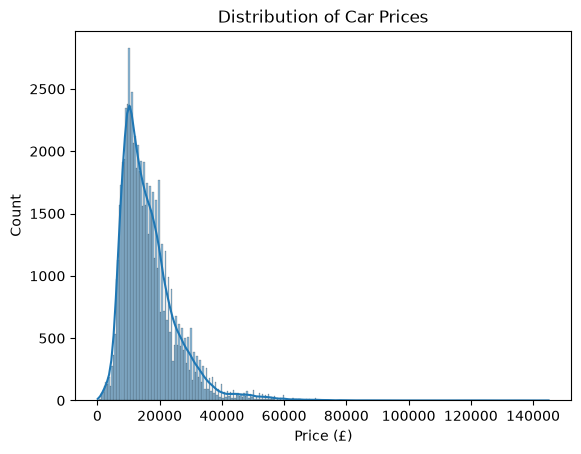

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins="auto", kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()



####  TODO: Write some conclusions 
#### This is a right skew - most data points are concentrated the left side
#### - Most cars are priced at the lower end
#### - A long tail extends to very expensive cars (£60,000–£140,000), but these are rare
#### - The mode (peak) is around £10,000–£15,000, meaning this is the most common price range
#### - Cars priced above ~£60,000 are rare outliers; they may need separate analysis if predicting or modeling prices

🧼 2. Boxplot of Price by Transmission Type
Compare prices across automatic vs manual cars.

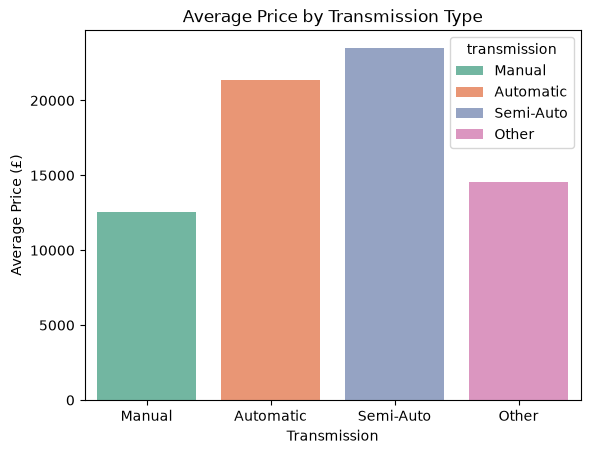

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use 'hue' to apply the palette per category
sns.barplot(
    x='transmission',
    y='price',
    data=df,
    hue='transmission',
    palette='Set2',
    errorbar=None,              
    legend=True             
)

plt.title('Average Price by Transmission Type')
plt.ylabel('Average Price (£)')
plt.xlabel('Transmission')
plt.xticks(rotation=0)
plt.show()

####  TODO: Write some conclusions 
#### highest average price - Semi-Auto cars costs around 24k £
#### manual cars are the cheapest
#### we can see a tendency for automatic and semi-automatic cars to be more expensive, which might be a good correlation indicator in the future
#### however, we see that none of these averages go above 23k, whereas our models go up to 145k. While it can help us adjust the price with a few thousand pounds, it does not mark the bound between high end and mid / entry level cars



⛽ 3. Boxplot of Price by Fuel Type
Helps assess how fuel type affects car pricing.

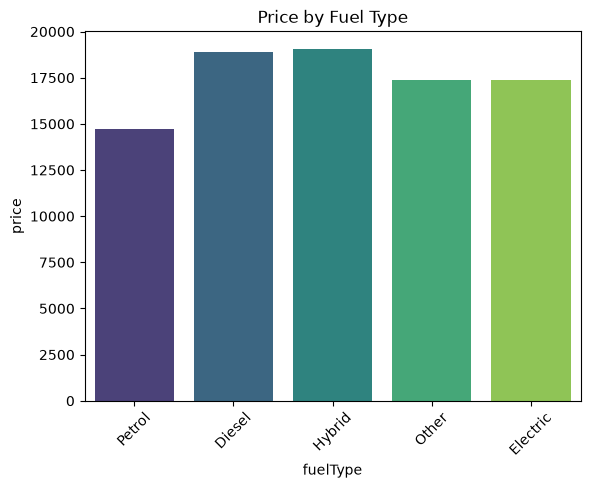

In [12]:


sns.barplot(x='fuelType', y='price', data=df, hue='fuelType',         
    palette='viridis',
    errorbar=None,              
    legend=False )
plt.title('Price by Fuel Type')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions 
#### - Petrol-fueled cars are the cheapest
#### - Hybrid-fueled cars have the highest prices
#### - all of these fuel types seem to be present in the mid-range cars section (15k - 20k), none of them are specific for high-end cars
#### - again, can be a good indicator for fine-tuning the price

🏷️ 4. Average Price per Car Make
Top 15 brands only for readability.


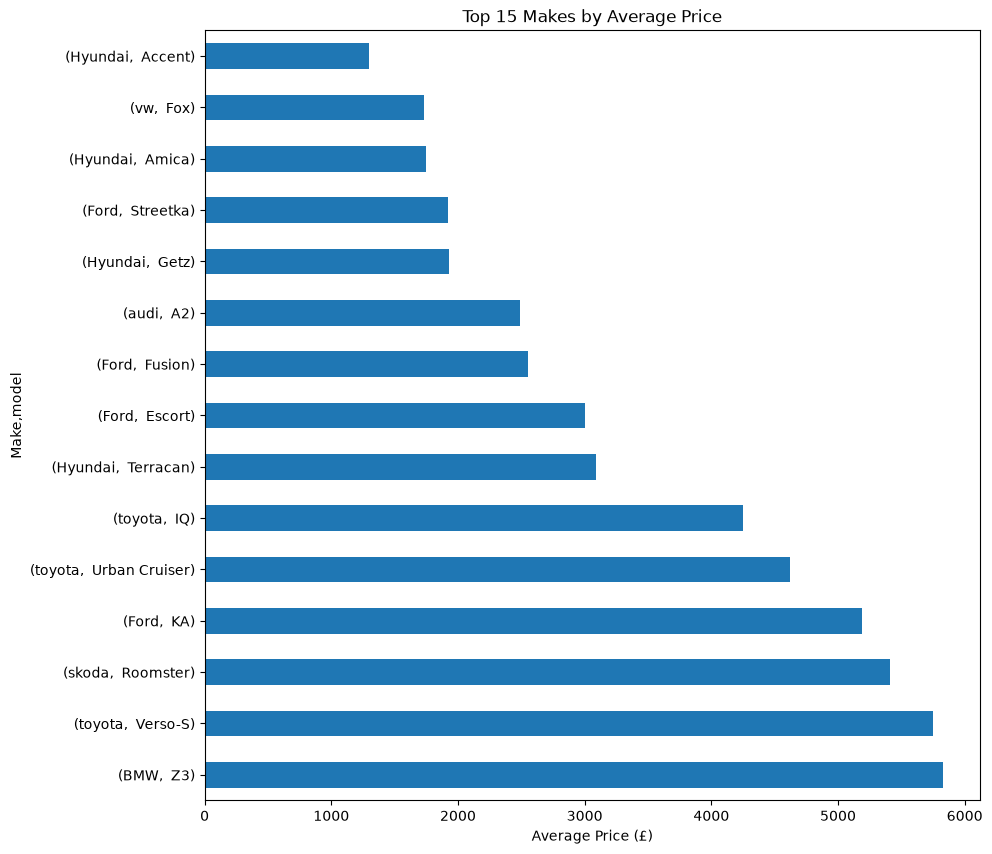

In [16]:
avg_price_by_make = df.groupby(['Make', 'model'])['price'].mean().sort_values(ascending=True).head(15)
avg_price_by_make.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Average Price (£)')
plt.title('Top 15 Makes by Average Price')
plt.gca().invert_yaxis()
plt.show()

####  TODO: Write some conclusions 
#### - Audi and BMW have the highest average prices
#### - Ford has the lowest average price
#### This metric (just the car brand) proves not to be a good indicator of a luxury car

---
#### Switching to models we can see that the most expensive model is audi R8 and the cheapest one is Hyundai Accent
#### With a mean price of ~24, both audi and BMW have mid-range models too (like other players), but they seem to control the high-end market, with only
#### A few outliers in the high-end market exist (Toyota supra or VW California) from what would be otherwise mid-range manufacturers (Toyota with average price of 13k and VW with 17k)
#### Seeing that the most expensive average for a model in the set (Audi R8) is 100k while the most expensive car out there is 145k means that there are some wild fluctuations inside a model's price range as well, based on other factors

📈 5. Scatterplot of Mileage vs. Price
See depreciation pattern as mileage increases.

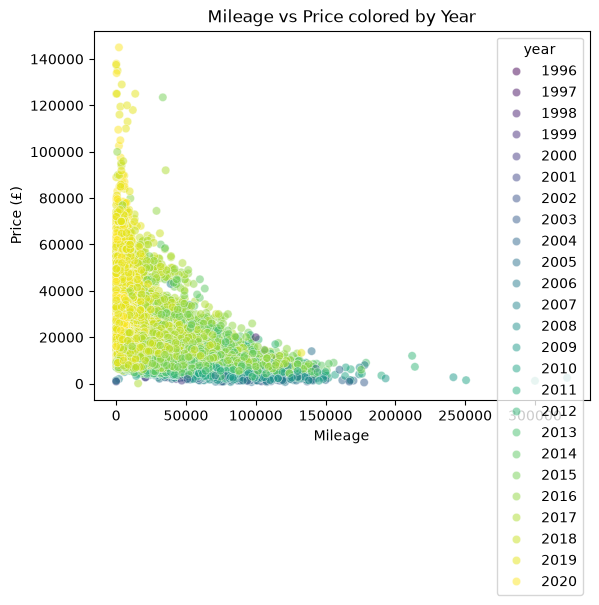

In [18]:
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5, hue='year', palette='viridis', legend='full')
plt.title('Mileage vs Price colored by Year')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()

####  TODO: Write some conclusions 
#### - Assigning a variable to hue map its levels to the color of the plots
#### - hue = year different colors for each year
#### - Newest cars (2018-2020) have low mileage and high prices 
#### - As the cars get older they increase in mileage, things that justify the low price
#### - High density of low priced cars
#### - Outliers: 
####      - new cars (expensive, low mileage)
####      - mid year cars (cheap, high mileage)



📅 6. Price vs Year
Understand how newer cars are priced.

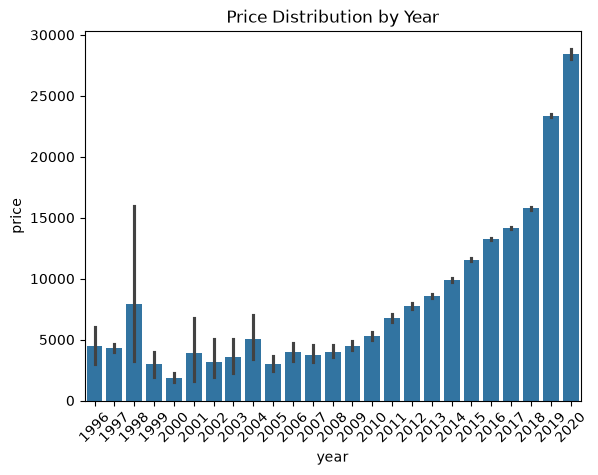

In [19]:
sns.barplot(x='year', y='price', data=df)
plt.title('Price Distribution by Year')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions

#### - price seems to be positively correlated with manufacturing year with a few exceptions around the year '98
#### - during the period ~2007-2018 the price seems to increase linearly with a few thousand pounds a year, but it increases exponentially in the last 2 years

⚙️ 7. Engine Size vs Price
Bigger engines tend to cost more — is it true?

C:\Users\CsavlovicsAlexandru\AppData\Local\Temp\ipykernel_19008\2309848177.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='engineSize', y='price', data=df, alpha=0.5,  palette='tab10', legend='full')
C:\Users\CsavlovicsAlexandru\AppData\Local\Temp\ipykernel_19008\2309848177.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


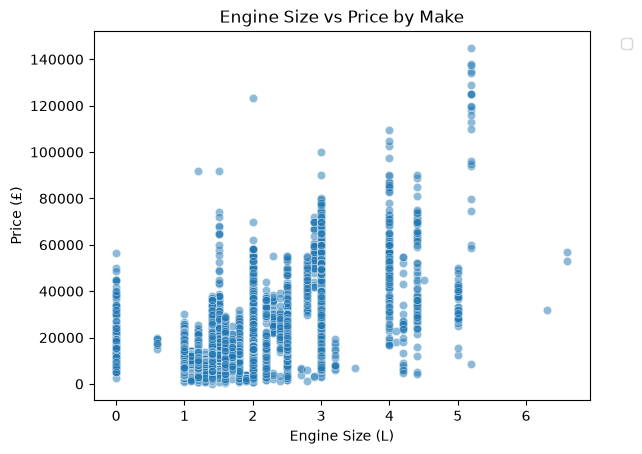

In [21]:
sns.scatterplot(x='engineSize', y='price', data=df, alpha=0.5,  palette='tab10', legend='full')
plt.title('Engine Size vs Price by Make')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (£)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

####  TODO: Write some conclusions

#### - Hyundai, Toyota, Škoda and VW focus  on lower capacity engines (<3L)
#### - Audi is avoiding the (0-2.5) liters range, focusing on more powerful engines only, while Ford and BMW serve all markets
#### - Most of the manufacturers have a limited variation of engine sizes, with only a few options to choose from (eg: BMW seems to have 5-6 main engine capacities)
#### - We can see that inside an engine size bracket we can have wild price fluctuations based on the brand (the 1.5 liter range has models from 0 pounds all the way to 90k)
#### - There doesn't seem to be a very strong correlation based on engine size and price alone. We have high and low values for the range [1, 2] with similar values being targeted by the range [4, 4.5]. This metric isn't (again) something based on which we can make the distinction between a mid-range and high-end car, but it can offer some fine-tuning.

🛣️ 8. MPG vs Price
Fuel efficiency vs cost.

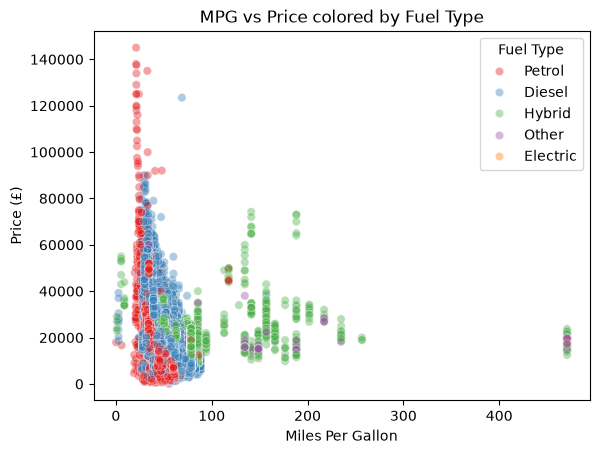

In [23]:
sns.scatterplot(x='mpg', y='price', data=df, alpha=0.4, hue='fuelType', palette='Set1')
plt.title('MPG vs Price colored by Fuel Type')
plt.xlabel('Miles Per Gallon')
plt.ylabel('Price (£)')
plt.legend(title='Fuel Type')
plt.show()

####  TODO: Write some conclusions

#### - Petrol cars are a tiny bit less fuel efficient than Diesel ones. Both of these fuel types are way less efficient than Hybrid ones (with a few exceptions)
#### - The majority of cars (including very expensive and very cheap ones) have an mpg between 10 and 90
#### - Petrol is the only fuel type that serves high-end cars (above90k) with only 1 exception
#### - Hybrid and Other fuel types are the only fuel types that get a higher than 100 mpg. These fuel types and efficiencies rarely exceed 60k pounds in price

### Let's see how these are correlated to the price

📦 9. Correlation Heatmap
Find linear relationships between numeric features.

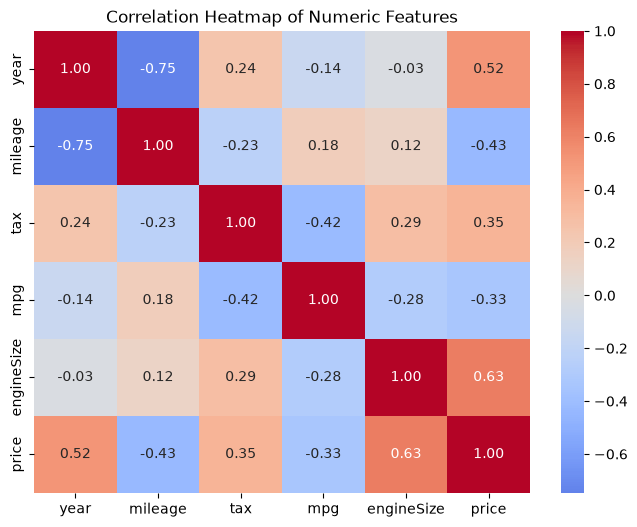

In [24]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [2]:
corr = df.corr(numeric_only=True)


C:\Users\CsavlovicsAlexandru\AppData\Local\Temp\ipykernel_25780\3789713215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')


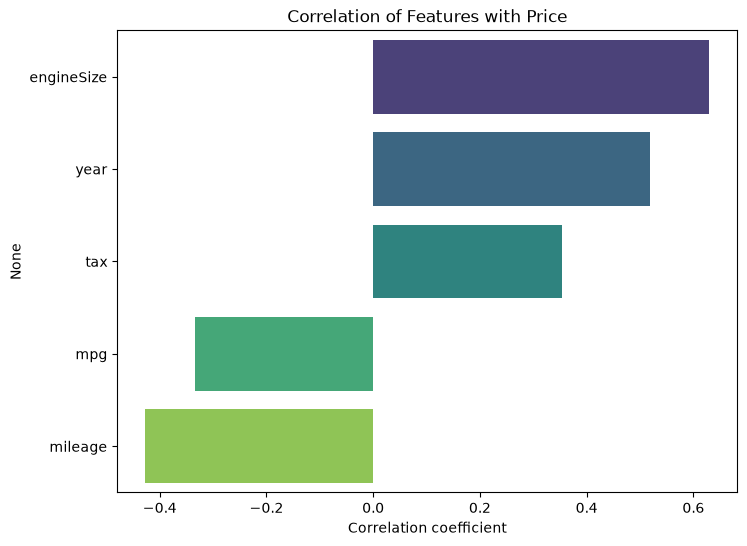

In [5]:

# Correlation with 'price' only
price_corr = corr['price'].sort_values(ascending=False)

# Drop 'price' itself for clarity
price_corr = price_corr.drop('price')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.show()

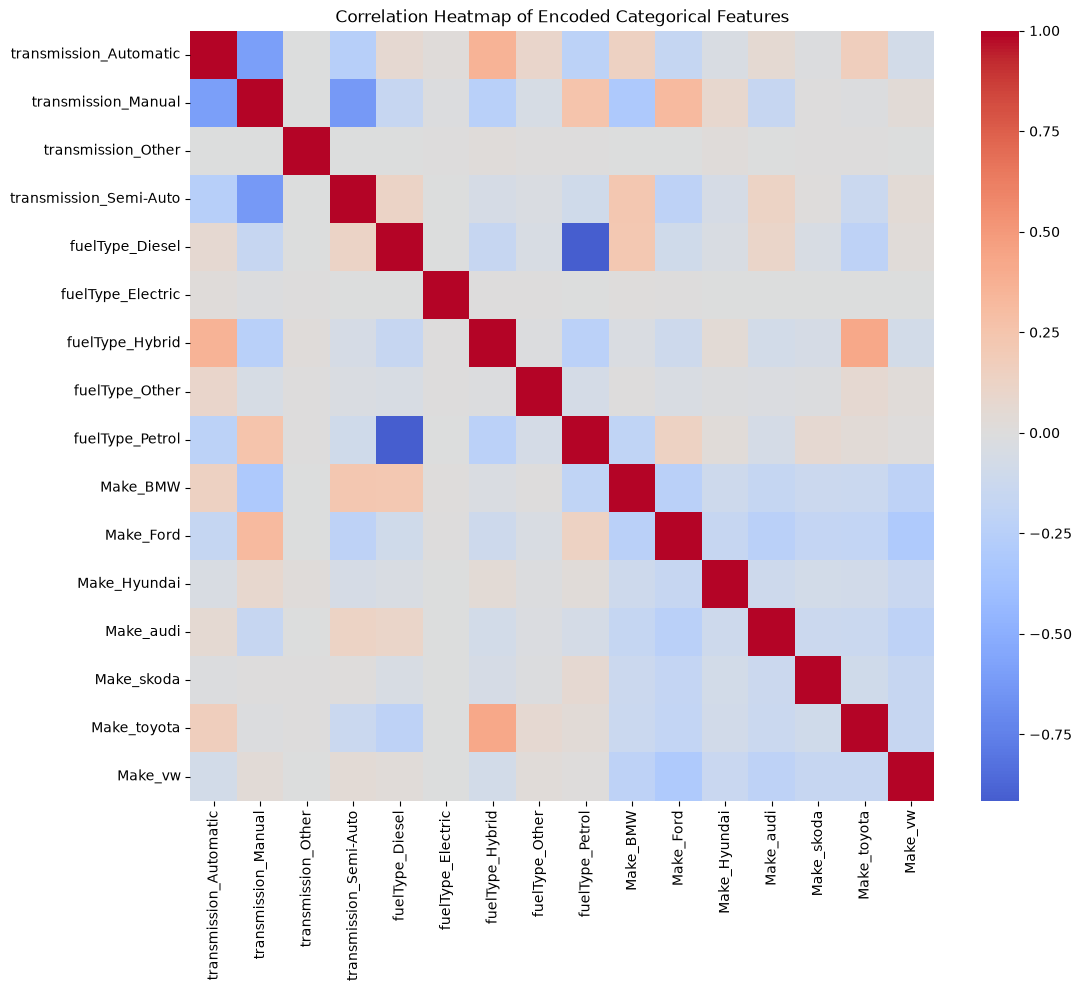

In [6]:
# Drop 'model' and encode categorical columns
df_no_model = df.drop(columns=['model'])
df_encoded = pd.get_dummies(df_no_model, columns=['transmission', 'fuelType', 'Make'])

# Select encoded categorical columns (exclude numeric)
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']
encoded_cols = [col for col in df_encoded.columns if col not in numeric_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[encoded_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Encoded Categorical Features')
plt.show()

#### Ok, we have a lot of correlations here so we can draw a lot of conclusions. When a correlation is approaching to 1, it means that there is a strong correlation between two features, and they are directly proportional to one another. Where the correlation is close to 0, it does not indicate to much for us, no correlation. If the correlation is approaching to -1, it means that there is an inverse proportionality between those features: where one increases, the other one decreaases.

#### TODO: Write at least 10 conclusions based on correlations

- year and mileage have a very strong correlation (0.75), making them perfect for predicting one another
- year and price have a 0.52 correlation, which is ok for predicting the price (50% of the cases respect this correlation)
- engine size and price (as seen from 2 of the charts) have a strong correlation (0.62), which is a good candidate for predicting the price
- the rest of the features have a weak correlation (<0.5), which means that they are not suitable alone for predicting the price. Maybe we would get a stronger correlation if we combine several features together to predict the price, but this isn't shown in these graphs. The only other correlation high enough to be relevant is mileage and price at 0.43
- an interesting correlation in the third graph is between fuel type petrol and diesel at 1. It makes sense that a petrol car isn't a diesel car, but this isn't present between other fuel types too (between diesel and electric is almost 0 correlation)
- it can be seen that hybrid engines are usually combined with a petrol fuel type engine rather than a diesel one
- out of all the manufacturers listed here, Toyota prefers the hybrid engine and the hybrid engine is preferred by Toyota
- it can be seen that hybrid engines require an automatic transmission with a small negative correlation for manual ones (meaning that if it's a manual most probably it isn't a hybrid)
- out of all the transmission out there, the highest correlation BMW has is with a semi-automatic transmission
- a slightly blue square can be seen in the bottom right corner, where the correlation between manufacturers is made. This makes sense, because a car cannot be built by 2 manufacturers

### Next steps:
- Feature Engineering: create new or transformed features that may better capture relationships (e.g. : Age of car: car_age = current_year - year, Binning mileage or engineSize into ranges, Log-transform skewed data (e.g., price, mileage), Interactions (e.g., mpg × engineSize))
- Encoding Categorical Features: perfect for transmission, fuelType, Make. Decide what to do with model column (high cardinality column)
- Feature Selection: 
     - You don't always want to keep everything. Good strategies include:
     - Use correlation with price (already done!)
     - SelectKBest, recursive feature elimination (RFE)
     - Model-based importance (e.g., .feature_importances_ from RandomForestRegressor)

#### Let's exemplify these two new features that were engineered based on already existing columns:

In [7]:
import datetime

current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2017,9
1,2016,10
2,2016,10
3,2017,9
4,2019,7


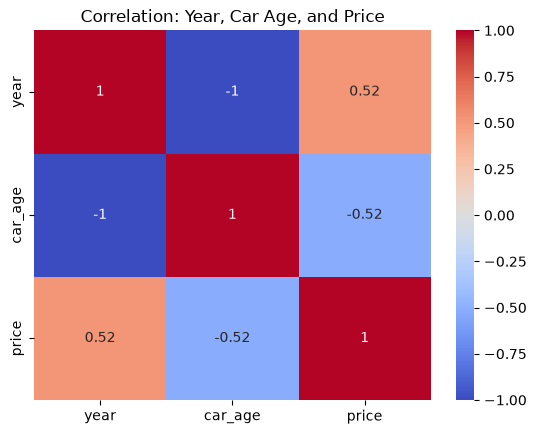

In [8]:
correlation_subset = df[['year', 'car_age', 'price']].corr()
sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Year, Car Age, and Price')
plt.show()

#### For example, it did not help. You can work with either car age or year, it gives the same stuff

In [9]:
# Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# Check distribution
df['mileage_bin'].value_counts()

mileage_bin
Low          28207
Very Low     23584
Medium       15994
High          4060
Very High      590
Name: count, dtype: int64

#### Create bins for mileage

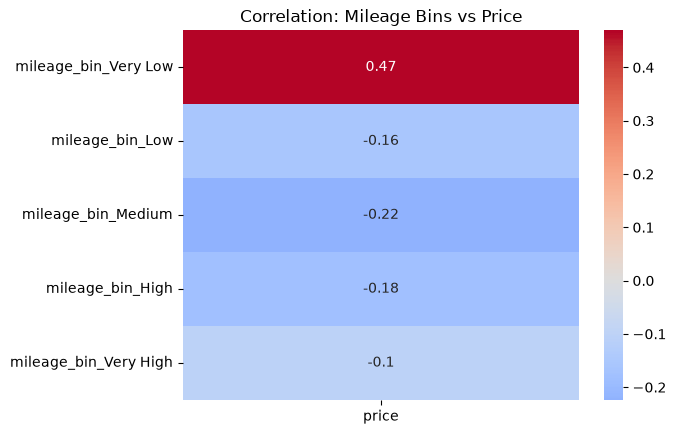

In [10]:
# 1. Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['mileage_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Mileage Bins vs Price')
plt.show()

#### TODO: is it helpful?
- the correlation between very_low mileage bin and price is moderate, with 25% of the variation being explained by the other variable
- the rest of the correlations are weak and almost useless

#### Let's go back to the dataset, since we have enough information

In [8]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,mileage_bin
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi,9,Low
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi,10,Medium
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi,10,Low
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi,9,Low
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi,7,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai,10,Low
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai,11,Medium
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai,9,Low
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai,8,Low


#### Categorical features need to be endoded

| Column         | Type             | Strategy                       | Notes                                    |
| -------------- | ---------------- | ------------------------------ | ---------------------------------------- |
| `transmission` | Categorical      | One-hot encoding               | Few categories                           |
| `fuelType`     | Categorical      | One-hot encoding               | Few categories                           |
| `Make`         | Categorical      | One-hot encoding               | Moderate number of brands (OK to encode) |
| `model`        | High-cardinality | Exclude or use target encoding | Too many unique values                   |
| `mileage_bin`  | Ordinal-ish      | Ordinal encoding or one-hot    | Low to high — either way works           |


In [11]:
mileage_bin_order = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['mileage_bin_encoded'] = df['mileage_bin'].map(mileage_bin_order)

# Now create df_encoded, drop 'model' and 'mileage_bin' (keep mileage_bin_encoded)
df_encoded = df.drop(columns=['model', 'mileage_bin'])

# One-hot encode categorical variables (except mileage_bin_encoded which is numeric now)
df_encoded = pd.get_dummies(df_encoded, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

In [10]:
df_encoded

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_bin_encoded,transmission_Manual,transmission_Other,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,9,1,True,False,...,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,10,2,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,10,1,True,False,...,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,9,1,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,7,0,True,False,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,10,1,True,False,...,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,11,2,True,False,...,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,9,1,True,False,...,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,8,1,True,False,...,False,False,False,True,False,True,False,False,False,False


#### Feature selection:  I will drop car_age since it is not helpful and also model because it has that huge cardinality

#### We have to decide to use mileage or binned column, mileage_bin_encoded. For now, we will stick to the original column

In [12]:
columns_to_drop = ['model', 'car_age', 'mileage_bin_encoded']  
df_clean = df_encoded.drop(columns=columns_to_drop, errors='ignore')
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,True,False,False,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,True,False,False,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,True,False,False,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,True,False,False,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,True,False,False,False,False,False,True,False,True,False,False,False,False


In [13]:
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [13]:
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
1,2016,16500,36203,20,64.2,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,2016,11000,29946,30,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
3,2017,16800,25952,145,67.3,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,2019,17300,1998,145,49.6,1.0,1,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,1,0,0,0,0,0,0,0,1,0,0,0,0
72431,2015,7830,59508,30,65.7,1.7,1,0,0,0,0,0,0,0,1,0,0,0,0
72432,2017,6830,13810,20,60.1,1.0,1,0,0,0,0,0,1,0,1,0,0,0,0
72433,2018,13994,23313,145,44.8,1.6,1,0,0,0,0,0,1,0,1,0,0,0,0


#### TODO: Consider improvements like Standardization or Normalization:

| Technique           | What it does                            | When to use                                                                                                                                                         |
| ------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Standardization** | Centers data to mean=0, std=1 (z-score) | When features have different units/scales, and your model assumes normality or is sensitive to scale (e.g., linear regression, logistic regression, SVM, k-NN, PCA) |
| **Normalization**   | Scales data to \[0,1] range             | When you want features in same scale but not necessarily centered, often useful for neural networks, distance-based models                                          |


# Next Steps for Your ML Pipeline

### 1. Split data into training and testing sets
- Use `train_test_split` (e.g., 80% train, 20% test) to evaluate your model’s performance on unseen data.
- We will have 2 types of data: the encoded ones, needed for most of the models, and the original ones, which we will use for CatBoost, to showcase the power of this model, which can handle categorical features without encoding them.

In [14]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.model_selection import train_test_split

# In order to feed the original data to the model, we have to prepare it a bit
# Firstly, drop the unnecessary columns
df_original = df.drop(columns=['mileage_bin', 'mileage_bin_encoded', 'car_age'])

# Then, define the categorical columns
cat_cols = ('model', 'transmission', 'fuelType', 'Make')

# Now, we have to ensure that categorical columns do not contain extra whitespaces
for col in cat_cols:
    df_original[col] = df_original[col].astype('str').str.strip()

# Finally, we can split the data
og_X = df_original.drop(columns=['price'])
og_y = df_original['price']
og_X_train, og_X_test, og_y_train, og_y_test = train_test_split(og_X, og_y, test_size=0.2, random_state=42)


In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((57948, 18), (14487, 18), (57948,), (14487,))


### 2. (Optional) Further feature engineering or selection
- Try feature importance or recursive elimination to reduce noise.
- Experiment with polynomial features or interaction terms if it makes sense.

### 3. Choose machine learning model(s)
- Start simple: Linear Regression, Decision Trees, Random Forest, Gradient Boosting.
- For regression, consider models like:  
  - Linear Regression  
  - RandomForestRegressor  
  - XGBoost / LightGBM  
  - Support Vector Regression (SVR)

I will go with 2 models based on Gradient Boosting and compare them. The first one is the original Gradient Boosting algorithm, and the second one is CatBoost, which is a model based on Gradient Boosting but is optimized for categorical features. CatBoost removes the need of encoding categorical features and works better on datasets with categorical features.

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor

# initialize the Gradient Boosting model
gb = GradientBoostingRegressor(random_state=42) # regressor because it's a regression, we predict continuous values

# initialize the CatBoost model. Notice that we have to tell the model which are the categorical columns, so it won't treat them as numerical
cb = CatBoostRegressor(random_state=42, verbose=0, cat_features=cat_cols)  # verbose=0 to suppress output

### 4. Cross-validation
- Use K-Fold Cross Validation (e.g., 5 or 10 folds) on training set for robust performance estimation.
- Tune hyperparameters via grid search or random search within CV.

Cross-validation is the step where we select the best model (in our case we compare Gradient Boosting and CatBoost) and also tune the hyperparameters.

I will do this with K-Fold Cross Validation, which splits the train data into k folds, trains the model on k-1 folds and validates it on the remaining fold. The process is repeated k times, ensuring that each fold is used for validation once. For this test we will use 5 folds.

During this process, a different model with different hyperparameters is trained and evaluated,and the best model is chosen. Let's see the results

In [20]:
from sklearn.model_selection import KFold, cross_val_score

# initialize KFold algorithm
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# in the previous experiment I didn't use GridSearchCV to tune the hyperparameters, I simply compared the models with cross-validation
# Results: Gradient Boosting MAE: 2003.652
#          CatBoost MAE (with encoded data): 1406.355
#          CatBoost MAE (with original, categorical data): 1222.265
#          training time for Gradient Boosting and CatBoost with original data (on best performance laptop power settings): 5m 54s

In [21]:
# hyperparameter search for Gradient Boosting; this trains 135 models
# Best GB params:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
# Best GB CV MAE:  1452.3692937319188
# train time (on best performance laptop power settings): 4m
from sklearn.model_selection import GridSearchCV

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.05, 0.01],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(gb, gb_params, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

gb_grid.fit(X_train, y_train)

print("Best GB params: ", gb_grid.best_params_)
print("Best GB CV MAE: ", -gb_grid.best_score_)

Best GB params:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best GB CV MAE:  1452.3692937319188


In [22]:
# hyperparameter search for CatBoost with original data; this trains 90 models
# Best CB params:  {'depth': 8, 'iterations': 500, 'learning_rate': 0.1}
# Best CB CV MAE:  1195.2958208905575
# train time (on best performance laptop power settings): 10m 15s
from sklearn.model_selection import GridSearchCV

cb_params = {
    'depth': [4, 6, 8],
    'learning_rate': [0.1, 0.05, 0.01],
    'iterations': [300, 500]
}

cb_grid = GridSearchCV(cb, cb_params, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
cb_grid.fit(og_X_train, og_y_train)

print("Best CB params: ", cb_grid.best_params_)
print("Best CB CV MAE: ", -cb_grid.best_score_)

Best CB params:  {'depth': 8, 'iterations': 500, 'learning_rate': 0.1}
Best CB CV MAE:  1195.2958208905575


In [24]:
# time to compare the 2 models and choose the best of the best
gb_best_mae = -gb_grid.best_score_
cb_best_mae = -cb_grid.best_score_

if gb_best_mae < cb_best_mae:
    print("Gradient Boosting is the best model")
    gb_best_model = GradientBoostingRegressor(**gb_grid.best_params_, random_state=42)
else:
    print("CatBoost is the best model")
    cb_best_model = CatBoostRegressor(**cb_grid.best_params_, random_state=42, verbose=0, cat_features=cat_cols)

CatBoost is the best model


We can see that the best model is CatBoost, with a MAE of 1195.295 and this will be the model that we will use for the final evaluation. As seen from previous experiments, the model uses the original data with categorical features, making use of the model's ability to handle categorical features.
It is also worth nothing that Gradient Boosting had a great improvement from the previous experiment, reducing its MAE from 2003.652 to 1452.369

In [26]:
# train the best model on the entire training set
# train time (on best performance laptop power settings): 41s
model = None
try:
    if gb_best_mae < cb_best_mae:
        print("Training gradient boosting model")
        gb_best_model.fit(X_train, y_train)
        model = gb_best_model
    else:
        print("Training CatBoost model")
        cb_best_model.fit(og_X_train, og_y_train)
        model = cb_best_model
except NameError:
    print("Model does not exist. Ensure that you created the models before!")

Training CatBoost model


In [28]:
# test the models accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

if model is not None:
    if isinstance(model, CatBoostRegressor):
        y_pred = model.predict(og_X_test)
    else:
        y_pred = model.predict(X_test)
else:
    print("Model does not exist. Ensure that you created the models before!")

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 1175.07
RMSE: 2025.10
R²: 0.954


MAE (Mean Absolute Error) = 1175.07
On average, your model's predicted car prices are off by about $1,175 from the actual prices. This is a direct measure of average prediction error in the same units as price.

RMSE (Root Mean Squared Error) = 2025.10
RMSE penalizes larger errors more than MAE because it squares the errors before averaging. An RMSE of ~$2,025 means larger errors exist, but overall the predictions are quite close. RMSE is more sensitive to outliers.

R² (Coefficient of Determination) = 0.954
This means your model explains about 95.4% of the variance in car prices. The closer to 1, the better the model fits the data. So 0.954 is excellent — your model predicts prices very well.

### 7. Visualize results
- Plot predicted vs actual prices scatter plot.
- Residual plots to check errors.
- Feature importance plots (for tree-based models).
- Learning curves if needed (to check for overfitting/underfitting).

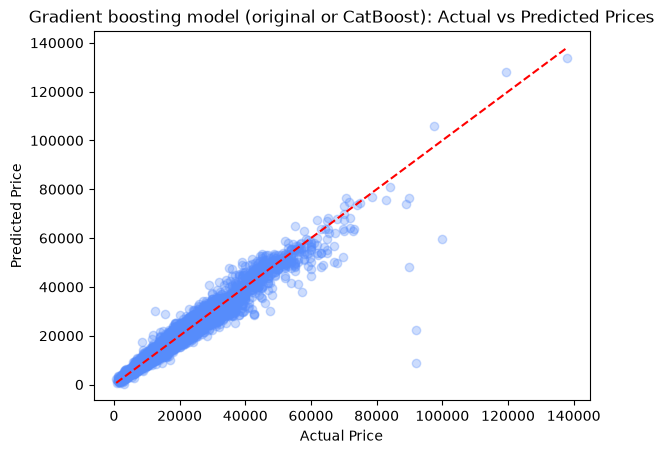

In [30]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient boosting model (original or CatBoost): Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

The plot shows that the predicted prices are very close to the actual prices, with only 4-5 large errors in the 90k-100k range

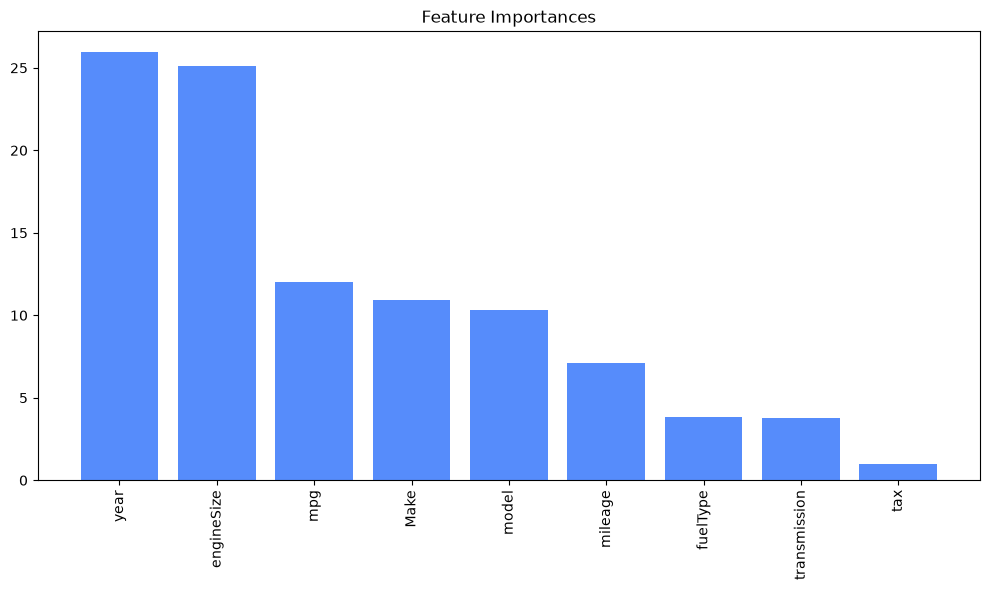

In [32]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = og_X.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()











### 8. Interpret and report
- Summarize model performance.
- Note any limitations or areas for improvement.

### 9. (Optional) Model improvement
- Try more advanced feature engineering.
- Try ensemble methods or stacking.
- Use domain knowledge for custom features.

### 10. Deployment (if needed)
- Prepare pipeline for new data.
- Save model using `joblib` or `pickle`.


### Interpreting
- the model generalizes well, with a RMSE of 2025.10 and an R² of 0.954. The graph confirms this, as most points lie near the diagonal line
- we see that the most important feature are year and engineSize, which makes sense, as people pay more for newer and more powerful cars. It is interesting that manufacturer (Make) and model are not as important as I thought, with an importance of only ~10
- we have some low-importance features like fuelType, transmission and tax (<5). We could remove them and make the model lighter and simpler, but they do not affect the performance

### Limitations
- as we have seen from the dataset analysis, there are some outliers in the dataset (eg: old cars), which can affect the model's performance. Removing and cleaning the dataset could improve the model's performance
- we also have rare categories (expensive cars above ~60k) which are not well represented in the dataset. This is seen by the higher R^2 score, which means that there are some moments when the model is off by a higher margin
- creating new features would make the model more robust and improve its performance. We have to try and test new combinations of parameters which might give us more insight
- in order to save time, we have searched for only a few hyperparameters for each model. A more thorough search could improve the model's performance as we find the best combination of hyperparameters
- searching for different models could also yield better performance, although we have used CatBoost, which is a model specifically designed for categorical features and is the only gradient boosting model that can handle categorical features without encoding them
- there are also real-world events that could drastically influence the price of cars without any correlation to the features in the dataset. Crises (like the 2008 financial crisis) or pandemics (like COVID-19) can affect the price of cars, but they are not present in the dataset and is currently out of reach for the model to predict